# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('../data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [2]:
monthly_mean = df['count'].resample('ME').mean()

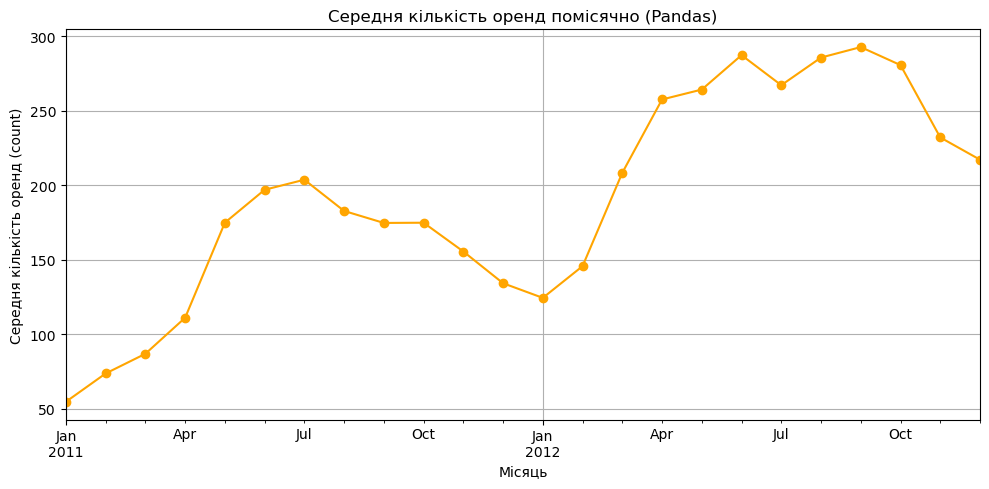

In [3]:
monthly_mean.plot(
    figsize=(10, 5),
    marker='o',       
    linestyle='-',   
    color='orange',
    title='Середня кількість оренд помісячно (Pandas)',
    xlabel='Місяць',
    ylabel='Середня кількість оренд (count)',
    grid=True
)

plt.tight_layout()
plt.show()

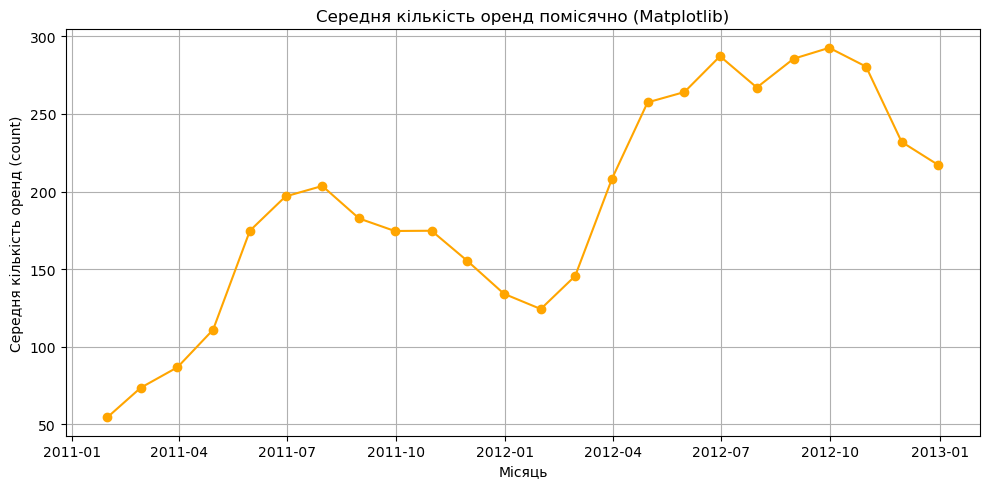

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(
    monthly_mean.index,
    monthly_mean.values,
    marker='o',       
    linestyle='-',     
    color='orange' 
)

plt.title("Середня кількість оренд помісячно (Matplotlib)")
plt.xlabel("Місяць")
plt.ylabel("Середня кількість оренд (count)")
plt.grid(True)

plt.tight_layout()
plt.show()

1. Різний формат дати
2. Різна сітка (на 1 графіку лише горизонтальні лінії)
3. Сам графік 1 починається і закінчується по рамках графіку, на 2 графіку видно відступи

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

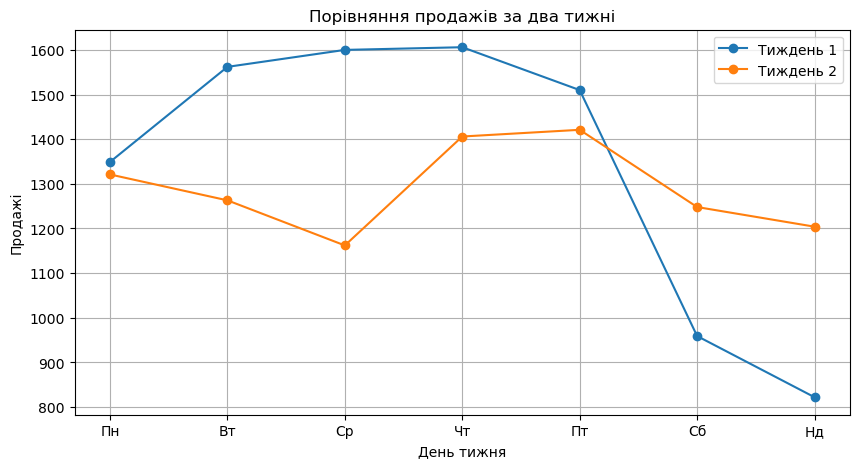

In [8]:
plt.figure(figsize=(10, 5))

plt.plot(days, sales_week1, marker='o', label='Тиждень 1')
plt.plot(days, sales_week2, marker='o', label='Тиждень 2')

plt.xticks(days, ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Нд'])  

plt.title('Порівняння продажів за два тижні')
plt.xlabel('День тижня')
plt.ylabel('Продажі')
plt.grid(True)
plt.legend()

plt.show()

І графік, і розрахунки підтверджують: продажі 2 тижня були бфльш стабфльнфшими: коливання менші, дані щільніші навколо середнього, розмах менший, середнє абсолютне відхилення і стандатне відхилення менші 

In [6]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень2

In [7]:
import numpy as np

sales_week1 = np.array([1349,1562,1600,1606,1510,959,822])
sales_week2 = np.array([1321,1263,1162,1406,1421,1248,1204])

print('Розмах (max - min)')
range_w1 = sales_week1.max() - sales_week1.min()
range_w2 = sales_week2.max() - sales_week2.min()
print('Тиждень 1:', range_w1)
print('Тиждень 2:', range_w2)

print('Середнє абсолютне відхилення')
mean_w1 = sales_week1.mean()
mean_w2 = sales_week2.mean()

mad_w1 = np.mean(np.abs(sales_week1 - mean_w1))
mad_w2 = np.mean(np.abs(sales_week2 - mean_w2))
print("Тиждень 1:", round(mad_w1, 2))
print("Тиждень 2:", round(mad_w2, 2))

print('Стандартне відхилення')
std_w1 = sales_week1.std()
std_w2 = sales_week2.std()
print("Тиждень 1:", round(std_w1, 2))
print("Тиждень 2:", round(std_w2, 2))

Розмах (max - min)
Тиждень 1: 784
Тиждень 2: 259
Середнє абсолютне відхилення
Тиждень 1: 259.14
Тиждень 2: 80.04
Стандартне відхилення
Тиждень 1: 300.0
Тиждень 2: 90.91


## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

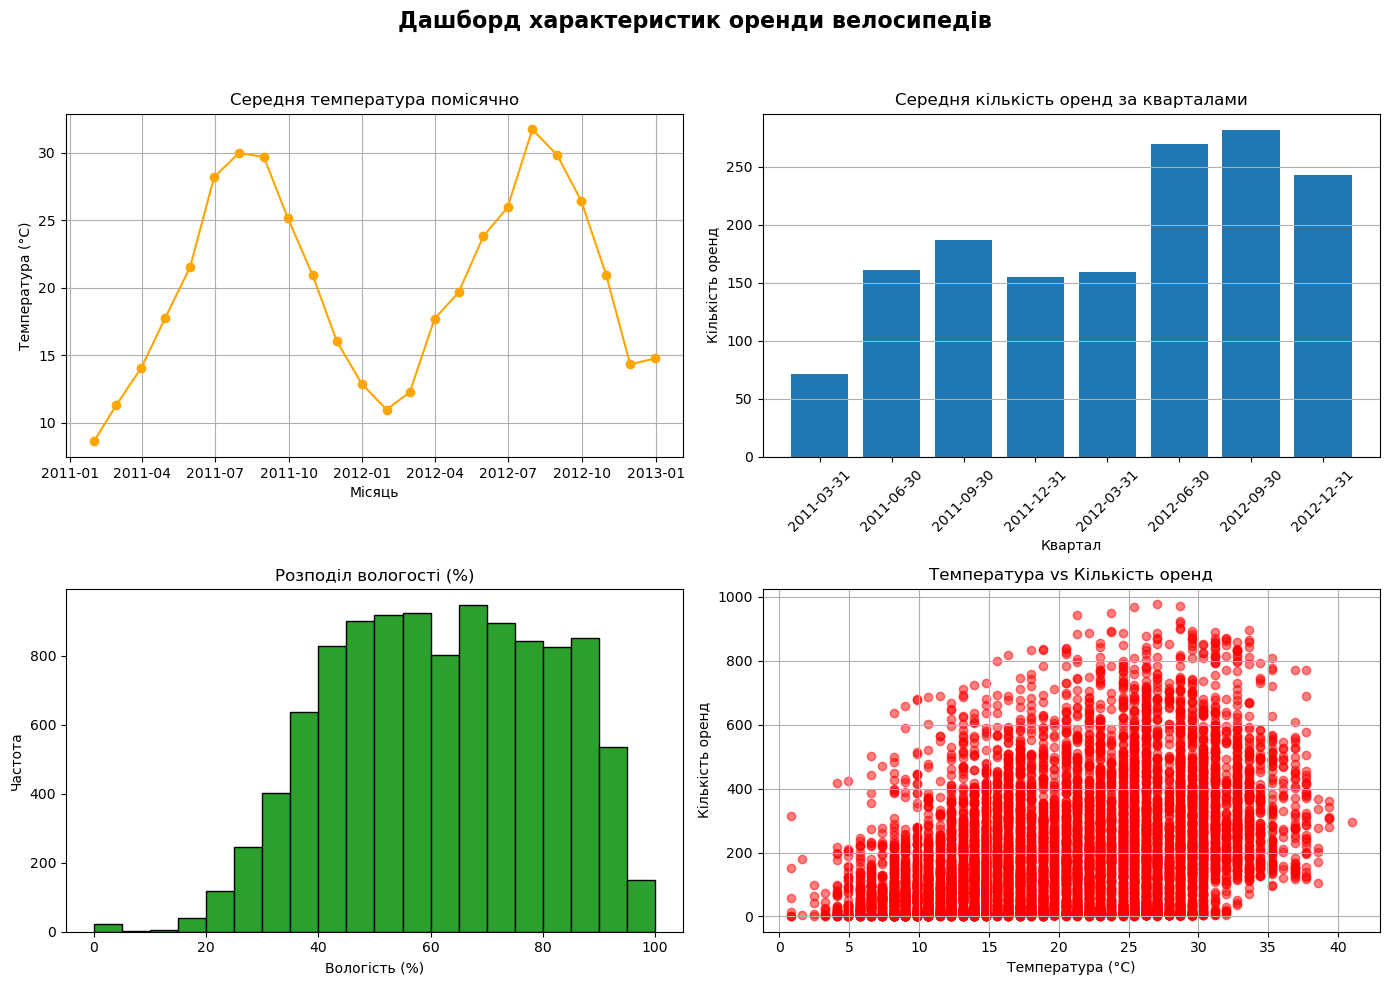

In [9]:
monthly_temp = df['temp'].resample('ME').mean()
quarterly_rent = df['count'].resample('QE').mean()
quarter_labels = quarterly_rent.index.strftime("%Y-%m-%d")
humidity = df['humidity']
temp = df['temp']
count = df['count']


plt.figure(figsize=(14, 10))
plt.suptitle('Дашборд характеристик оренди велосипедів', fontsize=16, fontweight='bold')


# Перший графік — лінійний
plt.subplot(2, 2, 1)
plt.plot(monthly_temp.index, monthly_temp.values, marker='o', color='orange')
plt.title('Середня температура помісячно')
plt.xlabel('Місяць')
plt.ylabel('Температура (°C)')
plt.grid(True)


# Другий графік — стовпчиковий
plt.subplot(2, 2, 2)
plt.bar(quarter_labels, quarterly_rent.values, color='tab:blue')
plt.title('Середня кількість оренд за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Кількість оренд')
plt.xticks(rotation=45)
plt.grid(axis='y')

# Третій графік — гістограма 
plt.subplot(2, 2, 3)
plt.hist(humidity, bins=20, color='tab:green', edgecolor='black')
plt.title('Розподіл вологості (%)')
plt.xlabel('Вологість (%)')
plt.ylabel('Частота')


# Четвертий — scatter plot
plt.subplot(2, 2, 4)
plt.scatter(temp, count, alpha=0.5, color='red')
plt.title('Температура vs Кількість оренд')
plt.xlabel('Температура (°C)')
plt.ylabel('Кількість оренд')
plt.grid(True)


plt.tight_layout(rect=[0, 0, 1, 0.95]) 
plt.show()

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

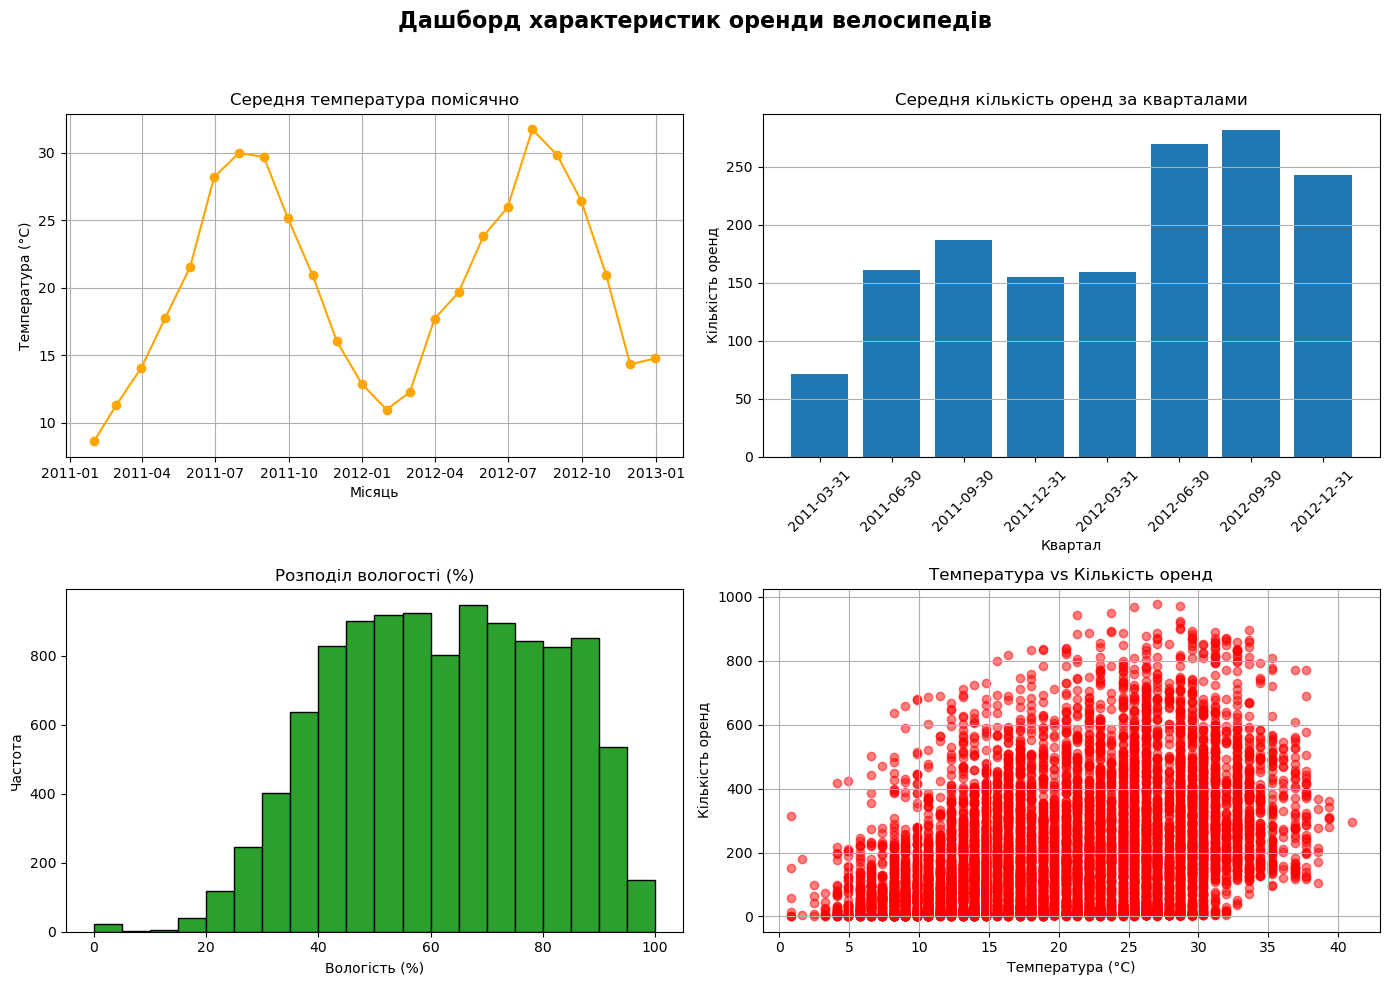

In [11]:
monthly_temp = df['temp'].resample('ME').mean()
quarterly_rent = df['count'].resample('QE').mean()
quarter_labels = quarterly_rent.index.strftime("%Y-%m-%d") 
humidity = df['humidity']
temp = df['temp']
count = df['count']

fig, ax = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Дашборд характеристик оренди велосипедів', fontsize=16, fontweight='bold')


# Лінійний графік 
ax[0, 0].plot(monthly_temp.index, monthly_temp.values, marker='o', color='orange')
ax[0, 0].set_title('Середня температура помісячно')
ax[0, 0].set_xlabel('Місяць')
ax[0, 0].set_ylabel('Температура (°C)')
ax[0, 0].grid(True)


# Стовпчикова діаграма
ax[0, 1].bar(quarter_labels, quarterly_rent.values, color='tab:blue')
ax[0, 1].set_title('Середня кількість оренд за кварталами')
ax[0, 1].set_xlabel('Квартал')
ax[0, 1].set_ylabel('Кількість оренд')
ax[0, 1].tick_params(axis='x', rotation=45)
ax[0, 1].grid(axis='y')


# Гістограма
ax[1, 0].hist(humidity, bins=20, color='tab:green', edgecolor='black')
ax[1, 0].set_title('Розподіл вологості (%)')
ax[1, 0].set_xlabel('Вологість (%)')
ax[1, 0].set_ylabel('Частота')


# Scatter plot
ax[1, 1].scatter(temp, count, alpha=0.5, color='red')
ax[1, 1].set_title('Температура vs Кількість оренд')
ax[1, 1].set_xlabel('Температура (°C)')
ax[1, 1].set_ylabel('Кількість оренд')
ax[1, 1].grid(True)


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Що покращено у версії з subplots()?

1.Код читабельніший і професійніший.

2.Легко керувати кожною підвіссю (ax[i, j]).

3.Можна синхронно змінювати стилі.


## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

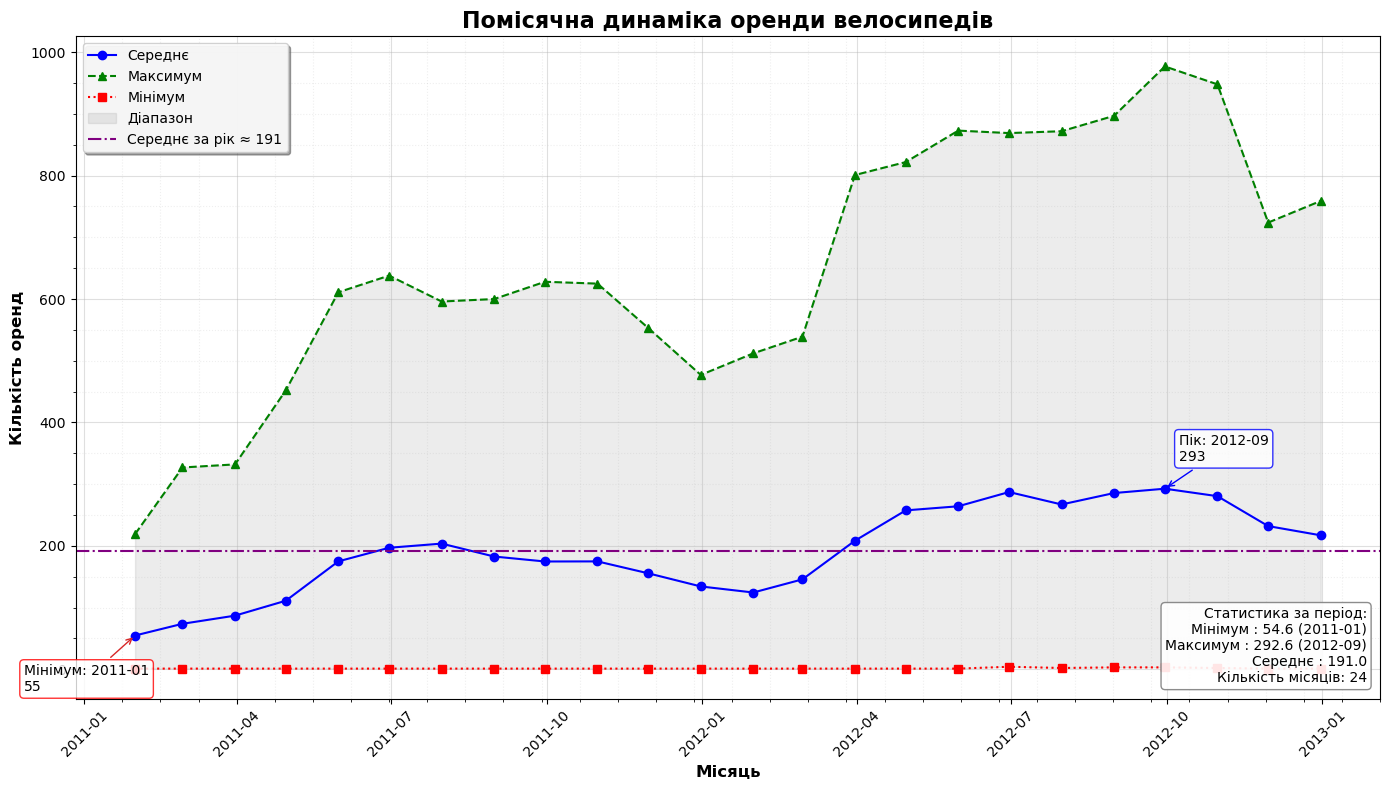

In [12]:
# 1. Помісячна статистика
monthly_mean = df['count'].resample('ME').mean()
monthly_min  = df['count'].resample('ME').min()
monthly_max  = df['count'].resample('ME').max()

# Середнє за весь період (для горизонтальної лінії)
overall_mean = monthly_mean.mean()

# Знаходимо місяці з макс/мін середнім значенням
max_month = monthly_mean.idxmax()
min_month = monthly_mean.idxmin()
max_value = monthly_mean.max()
min_value = monthly_mean.min()

# Для красивих підписів місяців у анотаціях
max_month_str = max_month.strftime("%Y-%m")
min_month_str = min_month.strftime("%Y-%m")

# 2. Створюємо фігуру та вісь
fig, ax = plt.subplots(figsize=(14, 8))

# 3. Три лінії: середнє, мінімум, максимум
ax.plot(
    monthly_mean.index, monthly_mean.values,
    linestyle='-', marker='o', color='blue',
    label='Середнє'
)

ax.plot(
    monthly_max.index, monthly_max.values,
    linestyle='--', marker='^', color='green',
    label='Максимум'
)

ax.plot(
    monthly_min.index, monthly_min.values,
    linestyle=':', marker='s', color='red',
    label='Мінімум'
)

# 4. Заливка між мінімумом та максимумом
ax.fill_between(
    monthly_mean.index,
    monthly_min.values,
    monthly_max.values,
    color='gray',
    alpha=0.15,
    label='Діапазон'
)

# 5. Горизонтальна лінія загального середнього
ax.axhline(
    overall_mean,
    color='purple',
    linestyle='-.',
    linewidth=1.5,
    label=f'Середнє за рік ≈ {overall_mean:.0f}'
)

# 6. Анотації для найвищого та найнижчого середнього
ax.annotate(
    f'Пік: {max_month_str}\n{max_value:.0f}',
    xy=(max_month, max_value),
    xytext=(10, 20),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='blue'),
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='blue', alpha=0.8)
)

ax.annotate(
    f'Мінімум: {min_month_str}\n{min_value:.0f}',
    xy=(min_month, min_value),
    xytext=(-80, -40),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='tab:red'),
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='red', alpha=0.8)
)

# 7. Двошарова сітка: основна + допоміжна
ax.grid(True, which='major', linestyle='-', alpha=0.4)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle=':', alpha=0.2)

# 8. Оформлення осей і заголовку
ax.set_title(
    'Помісячна динаміка оренди велосипедів',
    fontsize=16,
    fontweight='bold'
)
ax.set_xlabel('Місяць', fontsize=12, fontweight='bold')
ax.set_ylabel('Кількість оренд', fontsize=12, fontweight='bold')

# Поворот підписів місяців
plt.xticks(rotation=45)

# 9. Стилізована легенда з тінню
legend = ax.legend(
    loc='upper left',
    frameon=True,
    shadow=True,
    fontsize=10
)
legend.get_frame().set_alpha(0.9)

# 10. Текстовий блок зі статистикою в кутку
stats_text = (
    f"Статистика за період:\n"
    f"Мінімум : {min_value:.1f} ({min_month_str})\n"
    f"Максимум : {max_value:.1f} ({max_month_str})\n"
    f"Середнє : {overall_mean:.1f}\n"
    f"Кількість місяців: {len(monthly_mean)}"
)

ax.text(
    0.99, 0.02, stats_text,
    transform=ax.transAxes,
    fontsize=10,
    ha='right', va='bottom',
    bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.9)
)

plt.tight_layout()
plt.show()
